In [ ]:
!pip install datasets
# !pip install requests

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 491.4/491.4 kB 6.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 116.3/116.3 kB 4.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 193.6/193.6 kB 10.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 143.5/143.5 kB 6.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 194.8/194.8 kB 10.6 MB/s eta 0:00:00
  Attempting uninstall: fsspec
    Found existing installation: fsspec 2025.3.2
    Uninstalling fsspec-2025.3.2:
      Successfully uninstalled fsspec-2025.3.2
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
gcsfs 2025.3.2 requires fsspec==2025.3.2, but you have fsspec 2025.3.0 which is incompatible.
torch 2.6.0+cu124 requires nvidia-cublas-cu12==12.4.5.8; platform_system == "Linux" and platform_machine == "x86_64", but you have nvidia-cublas-cu12 12.5.3.2 which is 

In [ ]:
from datasets import load_dataset
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from collections import Counter
import nltk
from wordcloud import WordCloud
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import PorterStemmer
import string
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from wordcloud import WordCloud
from nltk.util import ngrams
from datasets import load_dataset

import re
import string
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer, PorterStemmer

# Download necessary NLTK resources (if not already downloaded)
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('wordnet')

nltk.download('punkt_tab')

# Download necessary NLTK resources
nltk.download("stopwords")
nltk.download("punkt")
# Download the stopwords dataset
nltk.download('stopwords')
nltk.download("punkt")

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!


True

In [ ]:
# Directly load the dataset
dataset = load_dataset("ErfanMoosaviMonazzah/fake-news-detection-dataset-English")

# Access the training data
train_data = dataset['train']
print(train_data)


# Convert to pandas DataFrame
df = pd.DataFrame(train_data)

# Display the first few rows of the dataset
print(df.head())

/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md:   0%|          | 0.00/487 [00:00<?, ?B/s]

train.tsv:   0%|          | 0.00/78.4M [00:00<?, ?B/s]

validation.tsv:   0%|          | 0.00/15.5M [00:00<?, ?B/s]

test.tsv:   0%|          | 0.00/22.0M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/30000 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/6000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/8267 [00:00<?, ? examples/s]

Dataset({
    features: ['Unnamed: 0', 'title', 'text', 'subject', 'date', 'label'],
    num_rows: 30000
})
   Unnamed: 0                                              title  \
0        2619  Ex-CIA head says Trump remarks on Russia inter...   
1       16043  YOU WON’T BELIEVE HIS PUNISHMENT! HISPANIC STO...   
2         876  Federal Reserve governor Powell's policy views...   
3       19963  SCOUNDREL HILLARY SUPPORTER STARTS “TrumpLeaks...   
4       10783  NANCY PELOSI ARROGANTLY DISMISSES Questions on...   

                                                text          subject  \
0  Former CIA director John Brennan on Friday cri...     politicsNews   
1  How did this man come to OWN this store? There...  Government News   
2  President Donald Trump on Thursday tapped Fede...     politicsNews   
3  Hillary Clinton ally David Brock is offering t...        left-news   
4  Pleading ignorance is a perfect ploy for Nancy...         politics   

                date  label  
0     July 22,

In [ ]:
df.head()

,Unnamed: 0,title,text,subject,date,label
0,2619,Ex-CIA head says Trump remarks on Russia inter...,Former CIA director John Brennan on Friday cri...,politicsNews,"July 22, 2017",1
1,16043,YOU WON’T BELIEVE HIS PUNISHMENT! HISPANIC STO...,How did this man come to OWN this store? There...,Government News,"Jun 19, 2017",0
2,876,Federal Reserve governor Powell's policy views...,President Donald Trump on Thursday tapped Fede...,politicsNews,"November 2, 2017",1
3,19963,SCOUNDREL HILLARY SUPPORTER STARTS “TrumpLeaks...,Hillary Clinton ally David Brock is offering t...,left-news,"Sep 17, 2016",0
4,10783,NANCY PELOSI ARROGANTLY DISMISSES Questions on...,Pleading ignorance is a perfect ploy for Nancy...,politics,"May 26, 2017",0


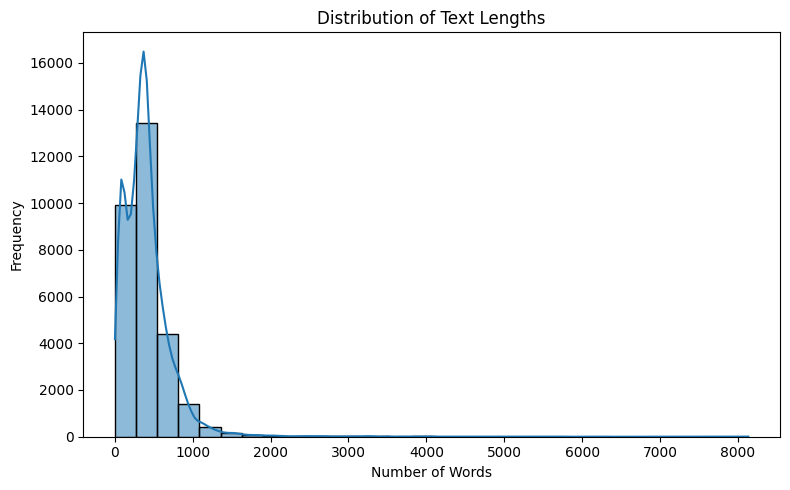

In [ ]:
# Calculate text length (in words)
df['text_length'] = df['text'].apply(lambda x: len(x.split()))

# Plot the distribution of text lengths
plt.figure(figsize=(8, 5))
sns.histplot(data=df, x='text_length', bins=30, kde=True)
plt.title('Distribution of Text Lengths')
plt.xlabel('Number of Words')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


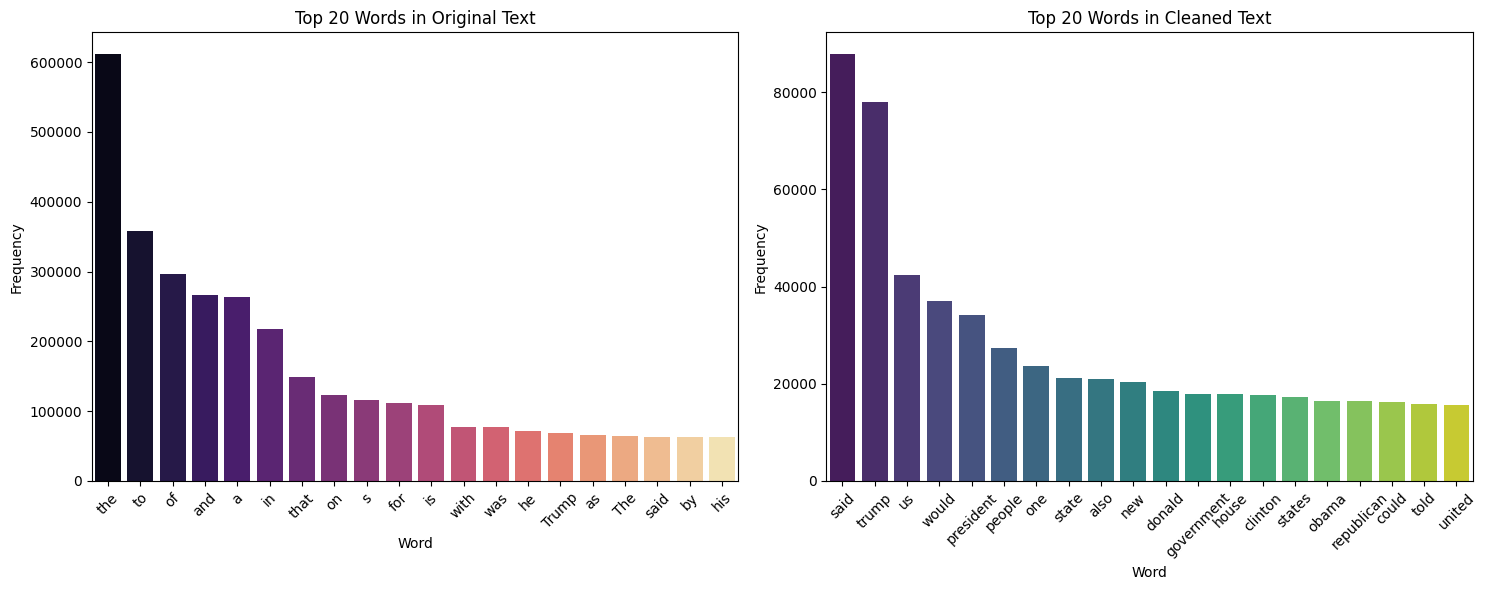

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import string
import nltk
from nltk.corpus import stopwords

# Download stopwords if not already done
nltk.download('stopwords')

# Define the English stopwords set
stop_words = set(stopwords.words('english'))

# Define a simple text cleaning function
def clean_text(text):
    if isinstance(text, str):
        text = text.lower()  # Convert to lowercase
        text = text.translate(str.maketrans('', '', string.punctuation))  # Remove punctuation
        words = text.split()  # Tokenize
        words = [word for word in words if word not in stop_words]  # Remove stopwords
        return " ".join(words)
    else:
        return ""

# Apply the cleaning function to create a new column
df['cleaned_text'] = df['text'].apply(clean_text)

# -------------------- WORD FREQUENCY ANALYSIS --------------------

# Tokenize words from original text
all_words_text = " ".join(df["text"].astype(str)).split()

# Tokenize words from cleaned text
all_words_cleaned = " ".join(df["cleaned_text"]).split()

# Count frequencies
word_freq_text = Counter(all_words_text)
word_freq_cleaned = Counter(all_words_cleaned)

# Get 20 most commen words
common_words_text = word_freq_text.most_common(20)
common_words_cleaned = word_freq_cleaned.most_common(20)

# Convert to DataFrames
df_common_text = pd.DataFrame(common_words_text, columns=["Word", "Frequency"])
df_common_cleaned = pd.DataFrame(common_words_cleaned, columns=["Word", "Frequency"])

# -------------------- PLOTTING --------------------
plt.figure(figsize=(15, 6))

# Original text
plt.subplot(1, 2, 1)
sns.barplot(data=df_common_text, x="Word", y="Frequency", palette="magma", hue="Word", legend=False)
plt.title("Top 20 Words in Original Text")
plt.xticks(rotation=45)

# Cleaned text
plt.subplot(1, 2, 2)
sns.barplot(data=df_common_cleaned, x="Word", y="Frequency", palette="viridis", hue="Word", legend=False)
plt.title("Top 20 Words in Cleaned Text")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()


<ipython-input-8-64bcb0368273>:34: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
<ipython-input-8-64bcb0368273>:44: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


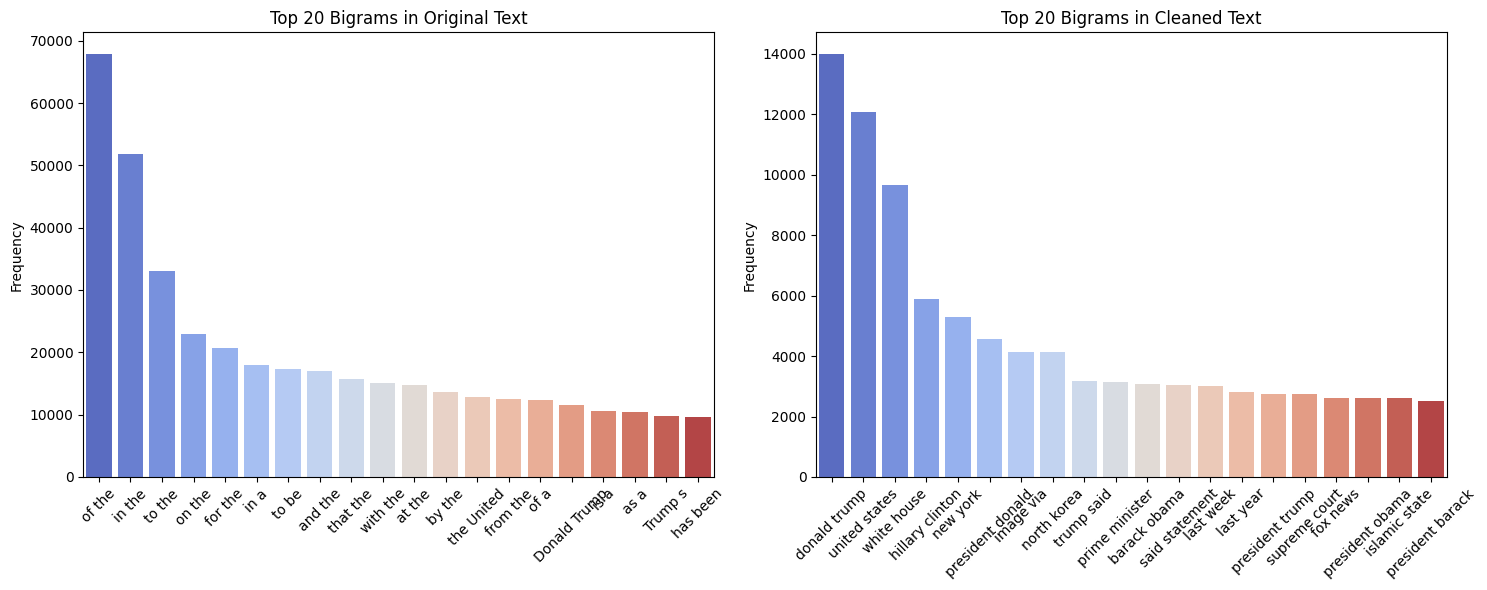

In [ ]:
# Function to get top n-grams (like bigrams, trigrams etc.)
def get_top_ngrams(text_data, n, top_n=20):
    # Combine all text into one string and split into words
    words = " ".join(text_data).split()

    # Create n-grams (groups of n words)
    n_grams = list(ngrams(words, n))

    # Count how often each n-gram appears
    ngram_counts = Counter(n_grams)

    # Return the most common ones
    return ngram_counts.most_common(top_n)

# ---------------- Get Bigrams (2-word combinations) ----------------

# Get top 20 bigrams from original text column
top_bigrams_text = get_top_ngrams(df["text"], n=2)

# Get top 20 bigrams from cleaned text column
top_bigrams_cleaned = get_top_ngrams(df["cleaned_text"], n=2)

# Convert bigrams to DataFrames for plotting
df_bigrams_text = pd.DataFrame(top_bigrams_text, columns=["Bigram", "Frequency"])
df_bigrams_cleaned = pd.DataFrame(top_bigrams_cleaned, columns=["Bigram", "Frequency"])

# ---------------- Plotting the Results ----------------

# Set figure size
plt.figure(figsize=(15, 6))

# Plot for original text bigrams
plt.subplot(1, 2, 1)  # 1 row, 2 columns, 1st plot
sns.barplot(
    x=[" ".join(b) for b in df_bigrams_text["Bigram"]],
    y=df_bigrams_text["Frequency"],
    palette="coolwarm"
)
plt.xticks(rotation=45)
plt.title("Top 20 Bigrams in Original Text")

# Plot for cleaned text bigrams
plt.subplot(1, 2, 2)  # 1 row, 2 columns, 2nd plot
sns.barplot(
    x=[" ".join(b) for b in df_bigrams_cleaned["Bigram"]],
    y=df_bigrams_cleaned["Frequency"],
    palette="coolwarm"
)
plt.xticks(rotation=45)
plt.title("Top 20 Bigrams in Cleaned Text")

# Adjust layout so labels don't overlap
plt.tight_layout()
plt.show()


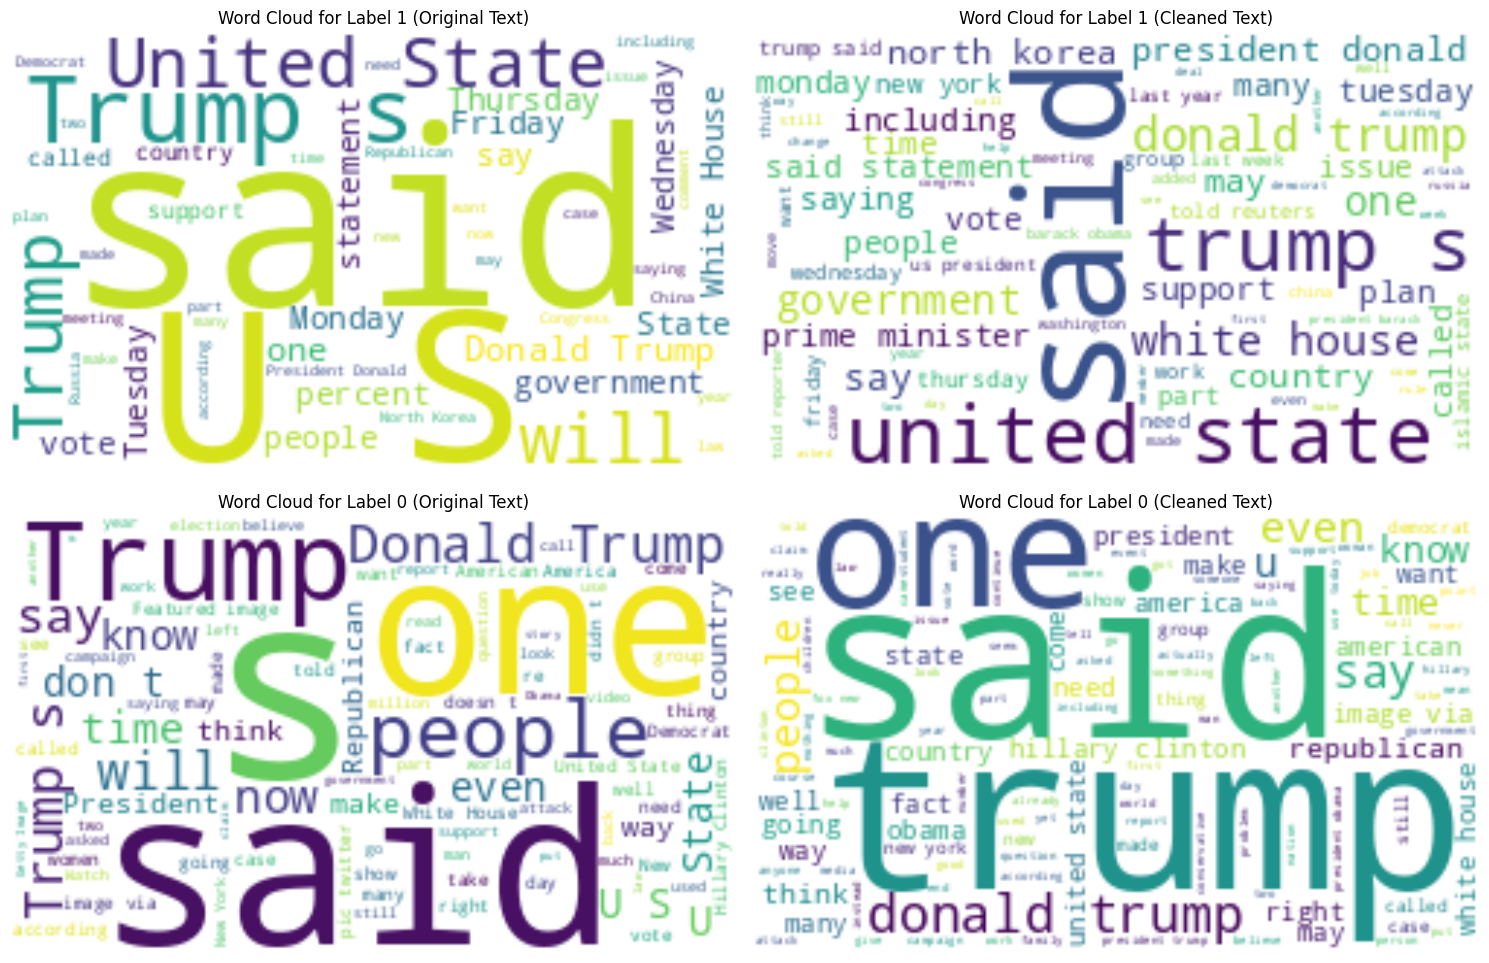

In [ ]:
# I want to see word clouds for each type of label (like 0 or 1)
# So I first get the unique labels from  dataframe
labels = df["label"].unique()
total_labels = len(labels)

# Making the whole figure larger so everything fits well
plt.figure(figsize=(15, 5 * total_labels))  # width x height

#  loop to create plots for each label
for i, label in enumerate(labels):

    # --- First: Word cloud from the original text column ---
    plt.subplot(total_labels, 2, i * 2 + 1)  # Left side for raw text

    # I filter rows that match the label and join all their text together
    all_text = " ".join(df[df["label"] == label]["text"])

    # I create a word cloud from the text
    wc_text = WordCloud(width=250, height=150, background_color="white").generate(all_text)

    # Show the word cloud
    plt.imshow(wc_text, interpolation="bilinear")
    plt.axis("off")  # Hide the axis lines
    plt.title(f"Word Cloud for Label {label} (Original Text)")

    # --- Second: Word cloud from the cleaned text column ---
    plt.subplot(total_labels, 2, i * 2 + 2)  # Right side for cleaned text

    # Join all cleaned text for the same label
    cleaned_text = " ".join(df[df["label"] == label]["cleaned_text"])

    # Create word cloud for cleaned text
    wc_cleaned = WordCloud(width=250, height=150, background_color="white").generate(cleaned_text)

    # Show it
    plt.imshow(wc_cleaned, interpolation="bilinear")
    plt.axis("off")
    plt.title(f"Word Cloud for Label {label} (Cleaned Text)")

# This helps make sure all plots fit nicely without overlapping
plt.tight_layout()
plt.show()


In [ ]:
# Create the TF-IDF Vectorizer object
# We want to extract the top 5000 most important words from the cleaned text
tfidf_vectorizer = TfidfVectorizer(max_features=5000)

# Fit the vectorizer on the 'cleaned_text' column and transform it into a TF-IDF matrix
# Each row in this matrix represents a document; each column represents a word
X_tfidf = tfidf_vectorizer.fit_transform(df["cleaned_text"])

# Convert the matrix to a DataFrame for easier viewing
# We use .toarray() to turn the sparse matrix into a regular array
# The column names will be the actual words from the cleaned text
X_tfidf_df = pd.DataFrame(X_tfidf.toarray(), columns=tfidf_vectorizer.get_feature_names_out())

# Display the first few rows to see the TF-IDF features
print(X_tfidf_df.head())





    10  100  1000  10000  100000   11   12   13   14        15  ...  younger  \
0  0.0  0.0   0.0    0.0     0.0  0.0  0.0  0.0  0.0  0.000000  ...      0.0   
1  0.0  0.0   0.0    0.0     0.0  0.0  0.0  0.0  0.0  0.081426  ...      0.0   
2  0.0  0.0   0.0    0.0     0.0  0.0  0.0  0.0  0.0  0.000000  ...      0.0   
3  0.0  0.0   0.0    0.0     0.0  0.0  0.0  0.0  0.0  0.000000  ...      0.0   
4  0.0  0.0   0.0    0.0     0.0  0.0  0.0  0.0  0.0  0.000000  ...      0.0   

   youth  youtube  zealand  zero  zika  zimbabwe  zone  zones  zuma  
0    0.0      0.0      0.0   0.0   0.0       0.0   0.0    0.0   0.0  
1    0.0      0.0      0.0   0.0   0.0       0.0   0.0    0.0   0.0  
2    0.0      0.0      0.0   0.0   0.0       0.0   0.0    0.0   0.0  
3    0.0      0.0      0.0   0.0   0.0       0.0   0.0    0.0   0.0  
4    0.0      0.0      0.0   0.0   0.0       0.0   0.0    0.0   0.0  

[5 rows x 5000 columns]


In [ ]:
#  input features (X) and target labels (y)
# X will be our TF-IDF features
# y will be the sentiment labels (e.g., positive, negative, neutral)
X = X_tfidf
y = df["label"]

# split  data into training and testing sets
# 80% of the data will be used to train the model, and 20% will be used to test it
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

#check the shape of the training and testing sets
print("Training data shape:", X_train.shape)
print("Testing data shape:", X_test.shape)


Training data shape: (24000, 5000)
Testing data shape: (6000, 5000)


In [ ]:
# 1. Train Naive Bayes Model
# We create an instance of the Naive Bayes model
nb_model = MultinomialNB()

# Now, let's train the Naive Bayes model using the training data (X_train, y_train)
nb_model.fit(X_train, y_train)

# After training, we make predictions on the test data (X_test)
nb_preds = nb_model.predict(X_test)

# 2. Train Logistic Regression Model
# Create an instance of the Logistic Regression model
lr_model = LogisticRegression(max_iter=1000)

# Train the Logistic Regression model using the training data
lr_model.fit(X_train, y_train)

#  predictions using the Logistic Regression model
lr_preds = lr_model.predict(X_test)

# 3. Train Random Forest Model
# Create an instance of the Random Forest model
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)

# Train the Random Forest model using the training data
rf_model.fit(X_train, y_train)

# Make predictions using the Random Forest model
rf_preds = rf_model.predict(X_test)


In [ ]:
# import necessary libraries
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

#  Create a function to evaluate the models
# This function will take the model name, actual values (y_test), and predicted values (y_pred) to print out the evaluation metrics
def evaluate_model(model_name, y_test, y_pred):
    # Print out the model name
    print(f"\n Model: {model_name}")

    # Calculate and print the accuracy score of the model
    accuracy = accuracy_score(y_test, y_pred)
    print("Accuracy:", accuracy)

    # Print the classification report (includes precision, recall, and F1-score)
    print("Classification Report:\n", classification_report(y_test, y_pred))

    # Print the confusion matrix (shows how many predictions were correct or incorrect)
    print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))

#  Now, let's evaluate the models we trained earlier
# For Naive Bayes model
evaluate_model("Naive Bayes", y_test, nb_preds)

# For Logistic Regression model
evaluate_model("Logistic Regression", y_test, lr_preds)

# For Random Forest model
evaluate_model("Random Forest", y_test, rf_preds)



 Model: Naive Bayes
Accuracy: 0.9401666666666667
Classification Report:
               precision    recall  f1-score   support

           0       0.95      0.94      0.94      3137
           1       0.93      0.94      0.94      2863

    accuracy                           0.94      6000
   macro avg       0.94      0.94      0.94      6000
weighted avg       0.94      0.94      0.94      6000

Confusion Matrix:
 [[2947  190]
 [ 169 2694]]

 Model: Logistic Regression
Accuracy: 0.9818333333333333
Classification Report:
               precision    recall  f1-score   support

           0       0.99      0.98      0.98      3137
           1       0.97      0.99      0.98      2863

    accuracy                           0.98      6000
   macro avg       0.98      0.98      0.98      6000
weighted avg       0.98      0.98      0.98      6000

Confusion Matrix:
 [[3061   76]
 [  33 2830]]

 Model: Random Forest
Accuracy: 0.9843333333333333
Classification Report:
               precisio

In [ ]:
import re

# Step 1: Define the text cleaning function
def data_cleaning(text):
    text = text.lower()  # convert to lowercase
    text = re.sub(r'[^a-z\s]', '', text)  # remove punctuation and numbers
    text = text.strip()  # remove leading/trailing spaces
    return text

# Step 2: Function to predict sentiment
def predict_sentiment(text, model):
    cleaned_text = data_cleaning(text)
    print("Cleaned Text:", cleaned_text)
    text_vectorized = tfidf_vectorizer.transform([cleaned_text])
    prediction = model.predict(text_vectorized)
    return prediction[0]

# Step 3: Test with a sample sentence
sample_text = "Trump is working hard for US."
predicted_sentiment = predict_sentiment(sample_text, lr_model)
print("Predicted Sentiment:", predicted_sentiment)


Cleaned Text: trump is working hard for us
Predicted Sentiment: 0
